## Adding MMP to PyHDD

In [1]:
import numpy as np
import control as ct
import control.matlab as ctm
import plant
import utils
from function_simulation import Function_simulation
from scipy import signal
from mfmdob_functions import signal_recovery_iir, wave_generator



     ______          _     _  _____    _____   
    (_____ \        | |   | |(____ \  (____ \  
     _____) ) _   _ | |__ | | _   \ \  _   \ \ 
    |  ____/ | | | ||  __)| || |   | || |   | |
    | |      | |_| || |   | || |__/ / | |__/ / 
    |_|       \__  ||_|   |_||_____/  |_____/  
              (____/                            
    
(v0.1.0)


/home/tomlichu/python-control/venv/lib/python3.12/site-packages/scipy/signal/_filter_design.py:1746: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  warnings.warn("Badly conditioned filter coefficients (numerator): the "


In [2]:


sim_result = Function_simulation(
    plant.Sys_Pc_vcm_c2,
    plant.Sys_Pc_pzt_c2,
    utils.get_Sys_Cd_vcm(),
    utils.get_Sys_Fm_vcm(),
    utils.get_Sys_Cd_pzt(),
    utils.get_Sys_Fm_pzt(),
    plant.Ts,
    plant.Mr_f,
    2
)


function_simulation: process 2 sim progress: 99.2%

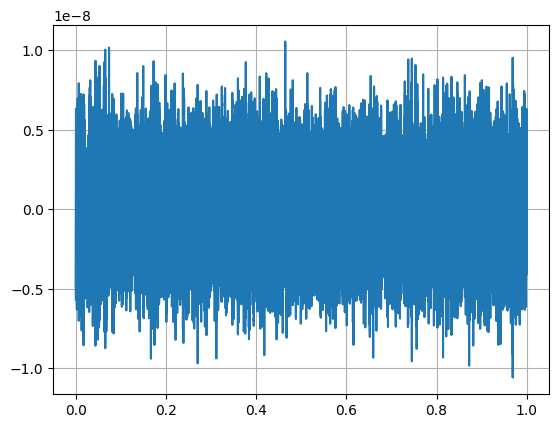

In [3]:
sim_result.keys()

import matplotlib.pyplot as plt
plt.plot(sim_result['time'], sim_result['yc'])
plt.grid()

1007999.9999994396


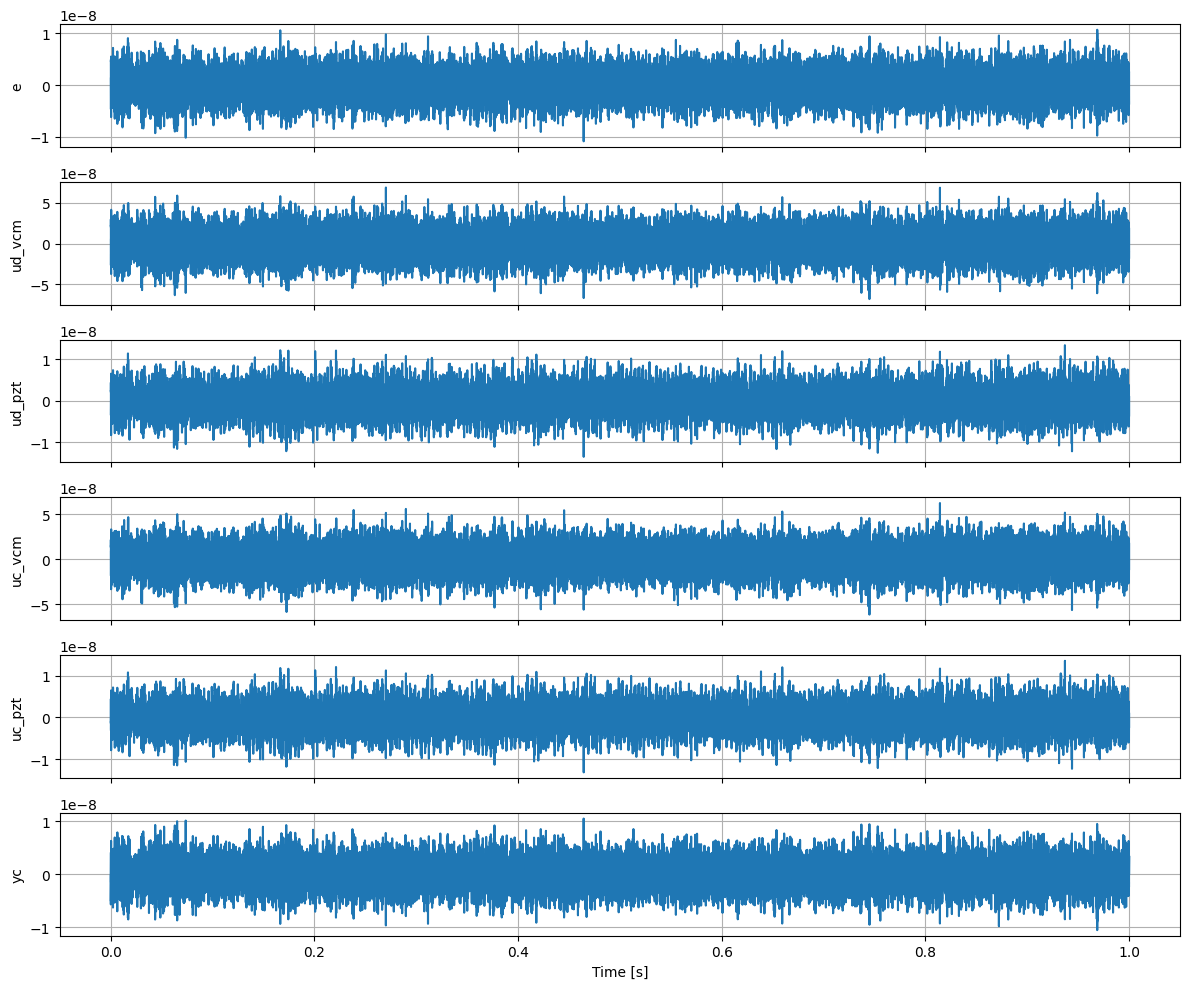

"\nsim_result['ud_vcm']\nsim_result['ud_pzt']\nsim_result['uc_vcm']\nsim_result['uc_pzt']\nsim_result['e']\n"

In [4]:
t = sim_result['time'] # runs at 100.8 kHz
t_fs = t[1]-t[0]
f_fs = 1/t_fs
print(f_fs)

fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True)
axs[0].plot(t, sim_result['e'])
axs[0].set_ylabel('e')
axs[0].grid(True)

axs[1].plot(t, sim_result['ud_vcm'])
axs[1].set_ylabel('ud_vcm')
axs[1].grid(True)

axs[2].plot(t, sim_result['ud_pzt'])
axs[2].set_ylabel('ud_pzt')
axs[2].grid(True)

axs[3].plot(t, sim_result['uc_vcm'])
axs[3].set_ylabel('uc_vcm')
axs[3].grid(True)

axs[4].plot(t, sim_result['uc_pzt'])
axs[4].set_ylabel('uc_pzt')
axs[4].grid(True)

axs[5].plot(t, sim_result['yc'])
axs[5].set_ylabel('yc')
axs[5].set_xlabel('Time [s]')
axs[5].grid(True)

plt.tight_layout()
plt.show()
"""
sim_result['ud_vcm']
sim_result['ud_pzt']
sim_result['uc_vcm']
sim_result['uc_pzt']
sim_result['e']
"""

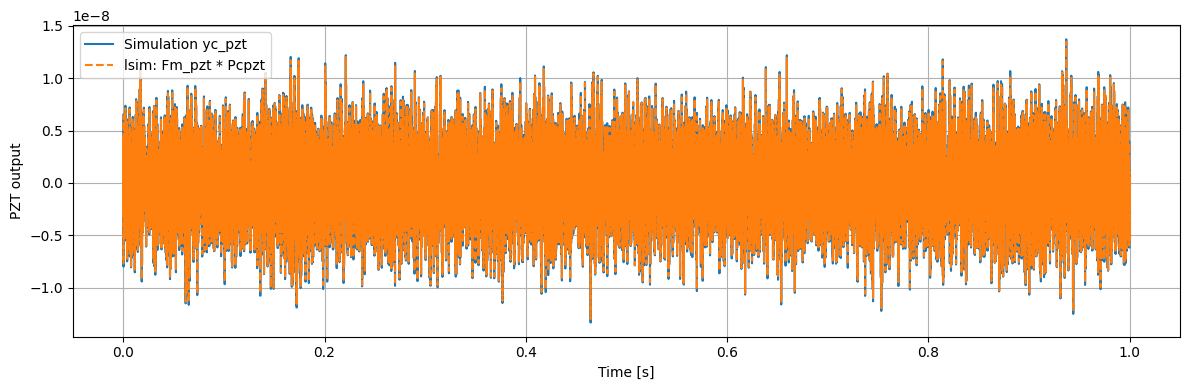

In [5]:
Ts = plant.Ts
Mr_f = plant.Mr_f
Ts_fast = Ts / Mr_f

Sys_Fm_pzt = utils.get_Sys_Fm_pzt()
Sys_Pc_pzt = plant.Sys_Pc_pzt_c2

Sys_Pc_pzt_d = ctm.c2d(ctm.ss(Sys_Pc_pzt), Ts_fast)

# Cascade: controller output -> multirate filter -> PZT plant
Sys_open_pzt = Sys_Pc_pzt_d * Sys_Fm_pzt

u_all = np.asarray(sim_result['ud_pzt']).squeeze()
t_all = np.asarray(sim_result['time']).squeeze()
yc_pzt_all = np.asarray(sim_result['yc_pzt']).squeeze()

step = int(20 / Mr_f)   # 20/2 = 10
u_fast = u_all[::step]
t_fast = t_all[::step]
yc_pzt_fast = yc_pzt_all[::step]
t_fast = np.arange(len(u_fast)) * Ts_fast
y_lsim, t_lsim, x_lsim = ctm.lsim(Sys_open_pzt, U=u_fast, T=t_fast)


plt.figure(figsize=(12,4))
plt.plot(t, sim_result['yc_pzt'], label='Simulation yc_pzt')
plt.plot(t_lsim, y_lsim, '--', label='lsim: Fm_pzt * Pcpzt')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('PZT output')
plt.tight_layout()
plt.show()

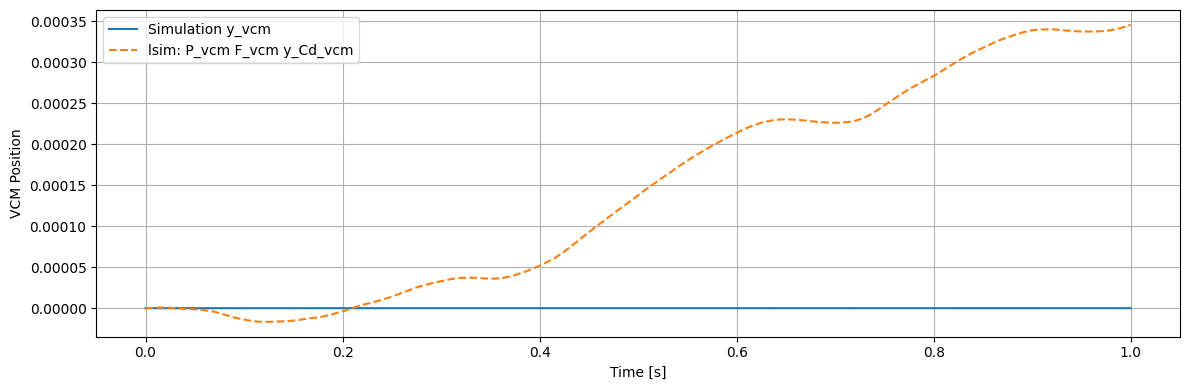

In [6]:
Ts = plant.Ts
Mr_f = plant.Mr_f
Ts_fast = Ts / Mr_f

# Systems
Sys_Fm_vcm = utils.get_Sys_Fm_vcm()
Sys_Pc_vcm = plant.Sys_Pc_vcm_c2

# Discretize plant at fast rate
Sys_Pc_vcm_d = ctm.c2d(ctm.ss(Sys_Pc_vcm), Ts_fast)

# Cascade: ud_vcm -> Fm_vcm -> Pc_vcm
Sys_open_vcm = Sys_Pc_vcm_d * Sys_Fm_vcm

u_all = np.asarray(sim_result['ud_vcm']).squeeze()
yc_vcm_all = np.asarray(sim_result['yc_vcm']).squeeze()

step = int(20 / Mr_f)     # 20/2 = 10

u_fast = u_all[::step]
yc_vcm_fast = yc_vcm_all[::step]

t_fast = np.arange(len(u_fast)) * Ts_fast

y_lsim, t_lsim, x_lsim = ctm.lsim(
    Sys_open_vcm,
    U=u_fast,
    T=t_fast
)

plt.figure(figsize=(12,4))

plt.plot(
    t_fast,
    yc_vcm_fast,
    label='Simulation y_vcm'
)

plt.plot(
    t_lsim,
    y_lsim,
    '--',
    label='lsim: P_vcm F_vcm y_Cd_vcm'
)

plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('VCM Position')

plt.tight_layout()
plt.show()

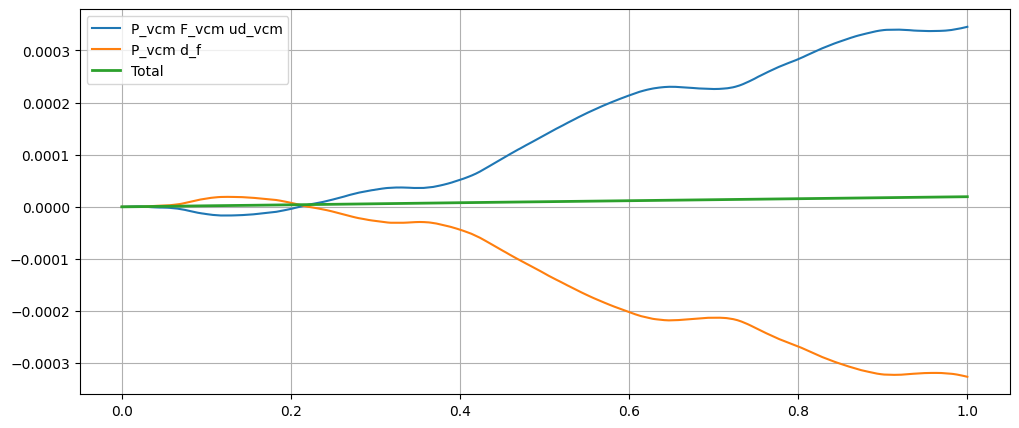

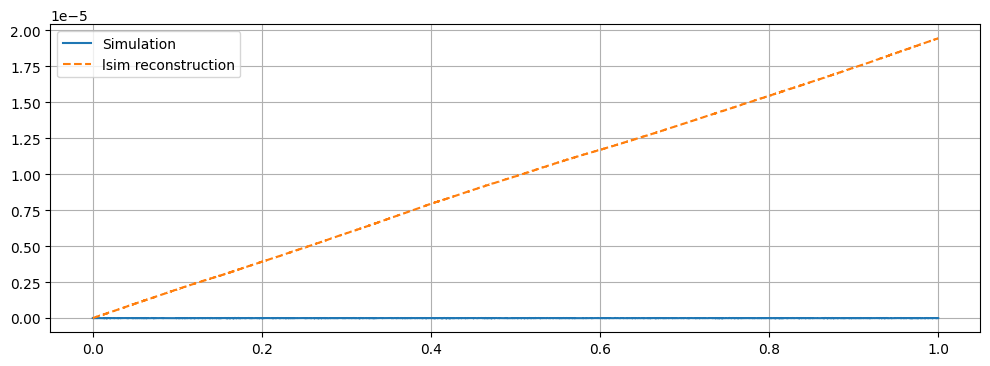

In [7]:
u_all  = np.asarray(sim_result['ud_vcm']).squeeze()
df_all = np.asarray(sim_result['df']).squeeze()

step = int(20 / Mr_f)

u_fast  = u_all[::step]
df_fast = df_all[::step]

t_fast = np.arange(len(u_fast)) * Ts_fast

y_control, _, _ = ctm.lsim(
    Sys_Pc_vcm_d * Sys_Fm_vcm,
    U=u_fast,
    T=t_fast
)

y_df, _, _ = ctm.lsim(
    Sys_Pc_vcm_d,
    U=df_fast,
    T=t_fast
)

y_vcm = y_control + y_df

plt.figure(figsize=(12,5))

plt.plot(t_fast, y_control, label='P_vcm F_vcm ud_vcm')
plt.plot(t_fast, y_df, label='P_vcm d_f')
plt.plot(t_fast, y_vcm, linewidth=2, label='Total')

plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t_fast, yc_vcm_fast, label='Simulation')
plt.plot(t_fast, y_vcm, '--', label='lsim reconstruction')
plt.grid(True)
plt.legend()
plt.show()

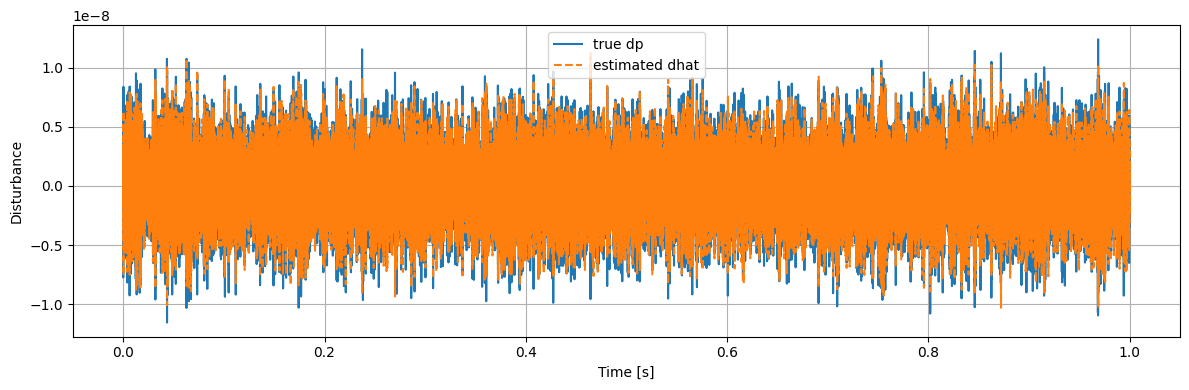

In [8]:
Ts = plant.Ts
Mr_f = plant.Mr_f
Ts_fast = Ts / Mr_f

# Systems
P_pzt = ctm.c2d(ctm.ss(plant.Sys_Pc_pzt_c2), Ts_fast)
P_vcm = ctm.c2d(ctm.ss(plant.Sys_Pc_vcm_c2), Ts_fast)

F_pzt = utils.get_Sys_Fm_pzt()
F_vcm = utils.get_Sys_Fm_vcm()

# Internal simulation grid -> fast-rate grid
step = int(20 / Mr_f)   # 10

yc = np.asarray(sim_result['yc']).squeeze()[::step]
ud_pzt = np.asarray(sim_result['ud_pzt']).squeeze()[::step]
ud_vcm = np.asarray(sim_result['ud_vcm']).squeeze()[::step]
df = np.asarray(sim_result['df']).squeeze()[::step]

t_fast = np.arange(len(yc)) * Ts_fast

# Disturbance observer model outputs
yhat_pzt, _, _ = ctm.lsim(P_pzt * F_pzt, U=ud_pzt, T=t_fast)
yhat_vcm, _, _ = ctm.lsim(P_vcm * F_vcm, U=ud_vcm, T=t_fast)
yhat_df,  _, _ = ctm.lsim(P_vcm, U=df, T=t_fast)

# Estimated fan/output disturbance
#dhat = yc - yhat_pzt.squeeze() - yhat_vcm.squeeze() - yhat_df.squeeze()
dhat = yc - yhat_pzt.squeeze() - yhat_vcm.squeeze()

fs_fast = 1 / Ts_fast

"""
# High-pass difference filter: y[n] = x[n] - x[n-1]
b_hp = np.array([1, -1])
a_hp = np.array([1])
"""

# 2nd-order Butterworth high-pass
fc = 2000     # Hz
b_hp, a_hp = signal.butter(
    N=2,
    Wn=fc,
    btype='highpass',
    fs=fs_fast)
dhat_hp = signal.lfilter(b_hp, a_hp, dhat)
dp_true = np.asarray(sim_result['dp']).squeeze()[::step]

plt.figure(figsize=(12,4))
plt.plot(t_fast, dp_true, label='true dp')
plt.plot(t_fast, dhat_hp, '--', label='estimated dhat')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Disturbance')
plt.tight_layout()
plt.show()

100800.0
RMS Error = 1.707239e-09
Relative RMS Error = 59.579%
Relative RMS Error for DOB = 68.595%
Fit = 40.421%


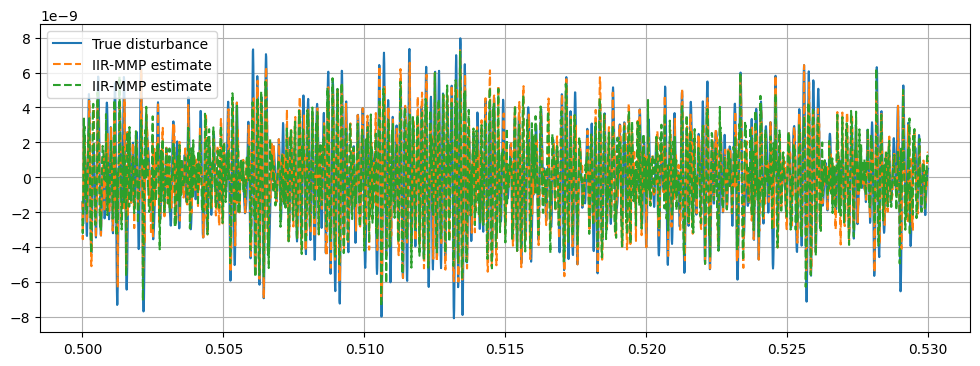

In [9]:

# Fast rate: 100.8 kHz
Ts_fast = plant.Ts / plant.Mr_f
fs_fast = 1 / Ts_fast
print(fs_fast)
# Downsample by 6 -> 16.8 kHz
L = 6
a_g = 0.95

dhat = yc - yhat_pzt.squeeze() - yhat_vcm.squeeze() - yhat_df.squeeze()
dhat_fast = np.asarray(dhat_hp).squeeze()
dhat_sparse = dhat_fast[::L]

dp_true_fast = np.asarray(sim_result['dp']).squeeze()[::step]
# Sparse measurement at 16.8 kHz
dp_true_sparse = dp_true_fast[::L]
￼
￼Page 1
￼Page 2 (Current page)
￼
￼

# Frequencies to recover
# f_hz = np.array([2200, 2937, 3300, 3545, 3980, 4220, 4380, 5072, 5370, 5850, 6660, 7670, 9200])

f_hz = np.array([4220, 4380, 5072, 5850, 6660, 7670, 9200])

# IIR-MMP reconstruction
dhat_mmp = signal_recovery_iir(
    input_signal=dhat_sparse,
    f_hz=f_hz,
    t_fs=Ts_fast,
    a_g=a_g,
    L=L
)

dp_mmp = signal_recovery_iir(
    input_signal=dp_true_sparse,
    f_hz=f_hz,
    t_fs=Ts_fast,
    a_g=a_g,
    L=L
)

N = min(len(dp_true_fast), len(dp_mmp))
dp_true_fast = dp_true_fast[:N]
dp_mmp = dp_mmp[:N]
dhat_mmp = dhat_mmp[:N]

t = np.arange(N) * Ts_fast

# Match lengths
N = min(len(dhat_fast), len(dhat_mmp))
dhat_fast = dhat_fast[:N]
dhat_mmp = dhat_mmp[:N]

t = np.arange(N) * Ts_fast
t_start = 0.5

idx0 = np.searchsorted(t, t_start)

dp_true_ss = dp_true_fast[idx0:]
dp_mmp_ss = dp_mmp[idx0:]
dhat_mmp_ss = dhat_mmp[idx0:]

rms_err = np.sqrt(
    np.mean(
        (dp_true_ss - dp_mmp_ss)**2
    )
)

rms_err_hat = np.sqrt(
    np.mean(
        (dp_true_ss - dhat_mmp_ss)**2
    )
)

rms_true = np.sqrt(
    np.mean(
        dp_true_ss**2
    )
)

rel_err = rms_err / rms_true
rel_err_hat = rms_err_hat / rms_true


fit = 100 * (1 - rel_err)

print(f"RMS Error = {rms_err:.6e}")
print(f"Relative RMS Error = {100*rel_err:.3f}%")
print(f"Relative RMS Error for DOB = {100*rel_err_hat:.3f}%")

print(f"Fit = {fit:.3f}%")

t_end = t_start + t[-1]*0.03
idx = (t >= t_start) & (t <= t_end)

plt.figure(figsize=(12,4))
plt.plot(t[idx], dp_true_fast[idx], label='True disturbance')
plt.plot(t[idx], dp_mmp[idx], '--', label='IIR-MMP estimate')
plt.plot(t[idx], dhat_mmp[idx], '--', label='IIR-MMP estimate')
plt.grid(True)
plt.legend()
plt.show()

<Figure size 1200x400 with 0 Axes>

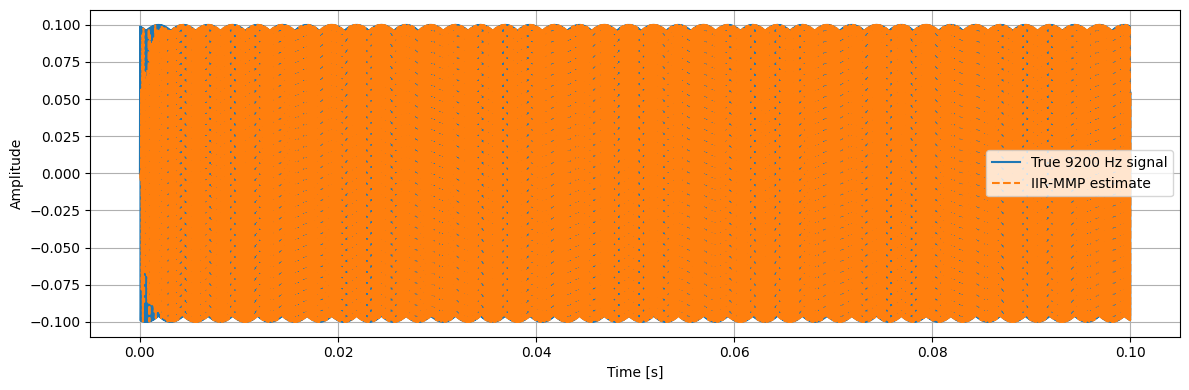

RMS error = 0.00376394732618681
Relative RMS error = 0.05323397956722225


In [10]:
f_hz = [9200]
amp = [0.1]
p_off = [0]
ts_fs = plant.Ts / plant.Mr_f
ts_ss = ts_fs*6
t_end = 0.1
out_ct, out_ss, out_fs = wave_generator(f_hz,amp,p_off,ts_ss,ts_fs,t_end)

y_est = signal_recovery_iir(
    input_signal=out_ss[1,:],
    f_hz=f_hz,
    t_fs=ts_fs,
    a_g=0.9,
    L=6
)
N = min(len(out_fs[1, :]), len(y_est))

t_true = out_fs[0, :N]
y_true = out_fs[1, :N]
y_est_plot = y_est[:N]
plt.figure(figsize=(12,4))

N = min(len(out_fs[1, :]), len(y_est))

t_true = out_fs[0, :N]
y_true = out_fs[1, :N]
y_est_plot = y_est[:N]

plt.figure(figsize=(12,4))
plt.plot(t_true, y_true, label='True 9200 Hz signal')
plt.plot(t_true, y_est_plot, '--', label='IIR-MMP estimate')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

N = min(len(out_fs[1,:]), len(y_est))

rms_err = np.sqrt(
    np.mean(
        (out_fs[1,:N] - y_est[:N])**2
    )
)

rms_true = np.sqrt(
    np.mean(
        out_fs[1,:N]**2
    )
)

print("RMS error =", rms_err)
print("Relative RMS error =", rms_err/rms_true)